# Main

In [1]:
##########################################################################
import os

# set the environment variable to control the number of threads
# NEEDS TO BE DONE BEFORE CCL IS IMPORTED
original_omp_num_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'

# Generic
import pandas as pd
import numpy as np
import scipy
from itertools import islice, cycle
import math
import sys
from scipy.integrate import odeint
from joblib import Parallel, delayed
import itertools
from importlib import reload
from functools import lru_cache
import scipy.integrate
import baccoemu
import subprocess
import multiprocessing

# cosmology
import pyccl as ccl
from astropy.io import fits
import yaml
import sacc
import time

# Generate data sets
from sklearn.datasets import make_blobs
import sklearn
#print(sklearn.__version__) # should be 1.3.2

# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# SRD Binning
import srd_redshift_distributions as srd
import binning

# Data Visualization
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.patches as mpatches
import matplotlib
#import seaborn as sns

# MCMC
import emcee
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import corner
#from chainconsumer import ChainConsumer, Chain, make_sample
from IPython.display import display, Math
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import gc

# Profiling
import cProfile
import pstats
from IPython.display import HTML

# nDGP NL and lin Pk
from nDGPemu import BoostPredictor

# f(R) emu (eMANTIS)
from emantis import FofrBoost

# Initialise and emulator instance.
emu_fR = FofrBoost()

2025-05-14 13:05:24.368544: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-14 13:05:24.397305: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-14 13:05:25.124813: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-14 13:05:25.374394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747224325.590968 2010212 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747224325.66

In [2]:
!which python

/home/c2042999/PCA_env/3.8.10/bin/python


In [3]:
print(emcee.__version__)
print(ccl.__version__)

3.1.6
3.0.0


In [4]:
from LikelihoodFuncts_PCADR_noparam import *

Loading model and related data


/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.24.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# Define cosmology
cosmo_universe = ccl.Cosmology(Omega_c = 0.269619, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)


In [6]:
# GET F(R) LINEAR POWER SPECTRUM, fiducial
##########################
idx_mdom = 0
a_solver = np.linspace(1/50,1.1,50)
k_solver = np.logspace(-5,4,200)

Soln = odeint(solverGrowth_nDGP, [a_solver[0], (E(cosmo_universe, a_solver[0])*a_solver[0]**3)], a_solver,\
              args=(cosmo_universe,[0,0,0,0,0]), mxstep=int(1e4))

Delta_GR = Soln.T[0]/Soln.T[0][idx_mdom]

Delta = []
for i in range(len(k_solver)):
    Soln = odeint(solverGrowth_fR, [a_solver[0], (E(cosmo_universe, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(cosmo_universe,[0,1e-4,0,0,0], k_solver[i]), mxstep=int(1e4))
    
    Delta_i = Soln.T[0]
    Delta.append(Delta_i/Delta_i[idx_mdom])

Delta = np.array(Delta)

# Get Pk linear in GR

interp_fR_Pk = scipy.interpolate.RegularGridInterpolator((k_solver,a_solver), (Delta / Delta_GR)**2,bounds_error=False, fill_value=1.0)
##########################

In [7]:
##########################################################################
#### Train the emulators ####
# Define the redshift interval and forecast years
redshift_range = np.linspace(0.01, 3.5, 500)
forecast_years = ["1", "10"]  # Assuming integers are appropriate

# Create a dictionary to store the redshift distributions
# for each forecast year and galaxy sample
redshift_distribution = {
    "sources": {},
    "lenses": {}
}

for year in forecast_years:
    source_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                               galaxy_sample="source_sample",
                                               forecast_year=year)
    lens_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                             galaxy_sample="lens_sample",
                                             forecast_year=year)

    redshift_distribution["sources"][year] = source_dist.get_redshift_distribution(normalised=True,
                                                                                   save_file=False)
    redshift_distribution["lenses"][year] = lens_dist.get_redshift_distribution(normalised=True,
                                                                                save_file=False)

# Uncomment to check if the dictionary is populated correctly
# print(redshift_distribution["sources"].keys())


bins = {
    "sources": {},
    "lenses": {}
}

# Perform the binning procedure
for year in forecast_years:
    bins["sources"][year] = binning.Binning(redshift_range, 
                                            redshift_distribution["sources"][year],
                                            year).source_bins(normalised=True,
                                                              save_file=False)
    bins["lenses"][year] = binning.Binning(redshift_range, 
                                           redshift_distribution["lenses"][year],
                                           year).lens_bins(normalised=True,
                                                           save_file=False)


#(5, 256)
Binned_distribution_lens = [list(bins["lenses"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_lens = np.append(Binned_distribution_lens,\
               [list(bins["lenses"]["1"].items())[i+1][1]], axis=0)

Binned_distribution_source = [list(bins["sources"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_source = np.append(Binned_distribution_source,\
               [list(bins["sources"]["1"].items())[i+1][1]], axis=0)


Bias_distribution_fiducial = np.array([1.562362*np.ones(len(redshift_range)),
                             1.732963*np.ones(len(redshift_range)),
                             1.913252*np.ones(len(redshift_range)),
                             2.100644*np.ones(len(redshift_range)),
                             2.293210*np.ones(len(redshift_range))])

binned_ell_test = bin_ell_kk(20, 1478.5, 13, Binned_distribution_source)

P_delta2D_GR_lin_universe = Get_Pk2D_obj_kk_GR_lin(cosmo_universe)
P_delta2D_GR_nl_universe = Get_Pk2D_obj_kk_GR_nl(cosmo_universe)

mockdata_test = Cell(binned_ell_test, \
                cosmo_universe, redshift_range , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,1e-5,1,0,0], linear=False, gravity_model="f(R)"),tracer1_type="k", tracer2_type="k")

mockdata_test = Cell(binned_ell_test, \
                cosmo_universe, redshift_range , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,1e-5,1,0,0], linear=False, gravity_model="nDGP"),tracer1_type="k", tracer2_type="k")


Training the emulator at aexp=0.3333... done.
Training the emulator at aexp=0.3650... done.
Training the emulator at aexp=0.4000... done.
Training the emulator at aexp=0.4167... done.
Training the emulator at aexp=0.4444... done.
Training the emulator at aexp=0.4762... done.
Training the emulator at aexp=0.5000... done.
Training the emulator at aexp=0.5263... done.
Training the emulator at aexp=0.5556... done.
Training the emulator at aexp=0.5882... done.
Training the emulator at aexp=0.6250... done.
Training the emulator at aexp=0.6667... done.
Training the emulator at aexp=0.7042... done.
Training the emulator at aexp=0.7692... done.
Training the emulator at aexp=0.8000... done.
Training the emulator at aexp=0.8696... done.
Training the emulator at aexp=0.9091... done.
Training the emulator at aexp=0.9524... done.
Training the emulator at aexp=1.0000... done.


In [8]:
value1 = [cosmo_universe["Omega_c"], 0.0, 0.0,cosmo_universe["A_s"]*1e9, cosmo_universe["h"],\
          cosmo_universe["n_s"],cosmo_universe["Omega_b"]*cosmo_universe["h"]**2,\
         Bias_distribution_fiducial[0][0], Bias_distribution_fiducial[1][0],\
         Bias_distribution_fiducial[2][0],Bias_distribution_fiducial[3][0],\
         Bias_distribution_fiducial[4][0]]

In [9]:
#### Define log likelihood #####
def log_likelihood(theta, Data, L_ch_inv,Data_fsigma8):
    Omega_c, mu0,Sigma0, A_s1e9, h, n_s, wb, b1, b2, b3, b4, b5 = theta 
    Bias_distribution = np.array([b1*np.ones(len(z)),
                             b2*np.ones(len(z)),
                             b3*np.ones(len(z)),
                             b4*np.ones(len(z)),
                             b5*np.ones(len(z))])
    #h = cosmo_universe["h"]
    #A_s = cosmo_universe["A_s"]
    A_s = A_s1e9*1e-9
    #n_s = cosmo_universe["n_s"]
    MGparams = [0.2,1e-4,1.0,mu0, Sigma0]

    cosmo = ccl.Cosmology(Omega_c = Omega_c, 
                      Omega_b = wb/h**2,
                      h = h,
                      n_s = n_s,
                      A_s = A_s)

    
    return loglikelihood(Data, cosmo, MGparams, L_ch_inv,Bias_distribution,Data_fsigma8)

#### Get Planck priors #####
sampler_Planck_arr = np.load("Prior_Planck_arr.npy")
mu_prior = [cosmo_universe['n_s'], cosmo_universe["Omega_b"]*cosmo_universe["h"]**2]
cov_prior = np.cov(sampler_Planck_arr.T)

#### Define log prior #####
def log_prior(theta):
    Omega_c, mu0,Sigma0, A_s1e9, h, n_s, wb, b1, b2, b3, b4, b5 = theta
    
    #flat priors
    if not (0.28 < Omega_c + wb/h**2 < 0.36  and\
            0.0 <= mu0 < 1.0 and -1.5 < Sigma0 < 1.5 \
            and 1.7 < A_s1e9 < 2.5 and 0.92 < n_s < 1 and 0.61 < h < 0.73 and 0.04 < wb/h**2 < 0.06 \
           and 0.8 < b1 < 3.0 and 0.8 < b2 < 3.0 and 0.8 < b3 < 3.0 and 0.8 < b4 < 3.0 and 0.8 < b5 < 3.0):
        return -np.inf

    gauss_funct = scipy.stats.multivariate_normal(mu_prior, cov_prior)

    return gauss_funct.logpdf([n_s, wb])


In [10]:
### Load and collect the data for likelihood
#npzfile = np.load("../Biases_parametrization/Data_storage_fR.npz")
npzfile = np.load("Data_storage_nDGP_partial.npz")
npzfile_GR = np.load("../Parameter_inference_GR/Data_storage_GR.npz")

C_ell_data_mock = [npzfile['C_ell_data'],npzfile['ell_data'],npzfile['z'],npzfile['Binned_distribution_source'],\
                    npzfile['Binned_distribution_lens'],20,1478.5,13]

Data_fsigma8= [npzfile['z_eff_fsigma8'], npzfile['fsigma8_data'],np.matrix(npzfile['invcov_fsigma8'])]

L_choleski_inv = np.matrix(npzfile_GR['L_ch_inv'])

gauss_invcov_rotated = np.matrix(npzfile_GR['Inverse_cov'])

z = npzfile['z']

/tmp/ipykernel_2010212/2753994817.py:9: PendingDeprecationWarning: the matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use regular ndarray.
  Data_fsigma8= [npzfile['z_eff_fsigma8'], npzfile['fsigma8_data'],np.matrix(npzfile['invcov_fsigma8'])]
/tmp/ipykernel_2010212/2753994817.py:11: PendingDeprecationWarning: the matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use regular ndarray.
  L_choleski_inv = np.matrix(npzfile_GR['L_ch_inv'])
/tmp/ipykernel_2010212/2753994817.py:13: PendingDeprecationWarning: the matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use re

## Tests

In [11]:
"""Test C_kk(ell) function"""

binned_ell = bin_ell_kk(20, 1478.5, 13, Binned_distribution_source)
"""nDGP"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,0,0,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,0,0,0,0], linear=False, gravity_model="nDGP"), tracer1_type="k", tracer2_type="k")

print("time1 = ", time.time() - start)

ell_testdata = testdata[0]
D_testdata_kk = testdata[1]

D_testdata_kk = (np.array(D_testdata_kk)).flatten()

start = time.time()
testdata_lin = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,0,0,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_lin_universe,interp_fR_Pk,cosmo_universe, [0.2,0,0,0,0], linear=True, gravity_model="nDGP"),tracer1_type="k", tracer2_type="k")

print("time2 = ", time.time() - start)

D_testdata_lin_kk = testdata_lin[1]
D_testdata_lin_kk = (np.array(D_testdata_lin_kk)).flatten()

del testdata, testdata_lin

"""fR"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata_fR = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,1e-4,1,0,0], linear=False, gravity_model="f(R)"),tracer1_type="k", tracer2_type="k")

print("time3 = ", time.time() - start)

ell_testdata_fR = testdata_fR[0]
D_testdata_kk_fR = testdata_fR[1]

D_testdata_kk_fR = (np.array(D_testdata_kk_fR)).flatten()

start = time.time()

testdata_lin_fR = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_lin_universe,interp_fR_Pk,cosmo_universe,[0.2,1e-4,1,0,0], linear=True, gravity_model="f(R)"),tracer1_type="k", tracer2_type="k")

print("time4 = ", time.time() - start)

D_testdata_lin_kk_fR = testdata_lin_fR[1]
D_testdata_lin_kk_fR = (np.array(D_testdata_lin_kk_fR)).flatten()

del testdata_fR, testdata_lin_fR

"""GR"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata_GR = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                P_delta2D_GR_nl_universe,tracer1_type="k", tracer2_type="k")
print("time5 = ", time.time() - start)

D_testdata_GR_kk = testdata_GR[1]
D_testdata_GR_kk = (np.array(D_testdata_GR_kk)).flatten()

start = time.time()
testdata_GR_lin = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                P_delta2D_GR_lin_universe,tracer1_type="k", tracer2_type="k")
print("time6 = ", time.time() - start)

D_testdata_GR_lin_kk = testdata_GR_lin[1]
D_testdata_GR_lin_kk = (np.array(D_testdata_GR_lin_kk)).flatten()

del testdata_GR, testdata_GR_lin

time1 =  0.17887592315673828
time2 =  0.21010899543762207
time3 =  0.21701312065124512
time4 =  0.07362818717956543
time5 =  0.04898977279663086
time6 =  0.05028176307678223


(195,)


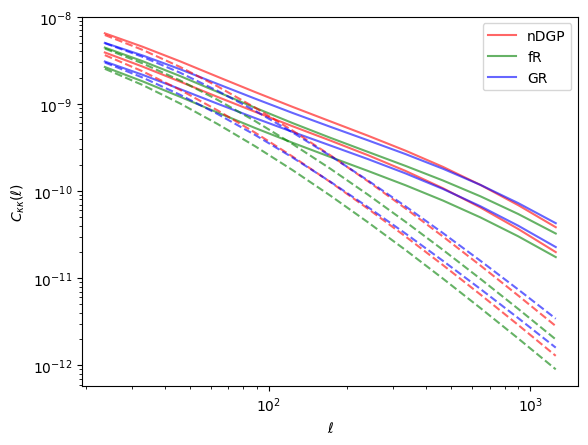

In [12]:
"""Plots: Test C_kk(ell) function"""

ell_bin_number = 13
print(D_testdata_kk.shape)


for j in range(2):
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_kk[j*ell_bin_number:(j+1)*ell_bin_number], "r", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_GR_kk[j*ell_bin_number:(j+1)*ell_bin_number], "g", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_kk_fR[j*ell_bin_number:(j+1)*ell_bin_number], "b", alpha= 0.6)
for j in range(2):
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_lin_kk[j*ell_bin_number:(j+1)*ell_bin_number], "r--", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_GR_lin_kk[j*ell_bin_number:(j+1)*ell_bin_number], "g--", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_lin_kk_fR[j*ell_bin_number:(j+1)*ell_bin_number], "b--", alpha= 0.6)


plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_{\kappa\kappa}(\ell)$')
plt.legend(["nDGP", "fR","GR"])
plt.xscale('log')
plt.yscale('log')
plt.show()

<>:7: DeprecationWarning: invalid escape sequence '\e'
<>:8: DeprecationWarning: invalid escape sequence '\e'
<>:7: DeprecationWarning: invalid escape sequence '\e'
<>:8: DeprecationWarning: invalid escape sequence '\e'
/tmp/ipykernel_1552329/4073861087.py:7: DeprecationWarning: invalid escape sequence '\e'
  plt.xlabel("$\ell$",fontsize=16)
/tmp/ipykernel_1552329/4073861087.py:8: DeprecationWarning: invalid escape sequence '\e'
  plt.ylabel("$C^{ij}_{AB}(\ell)$",fontsize=16)


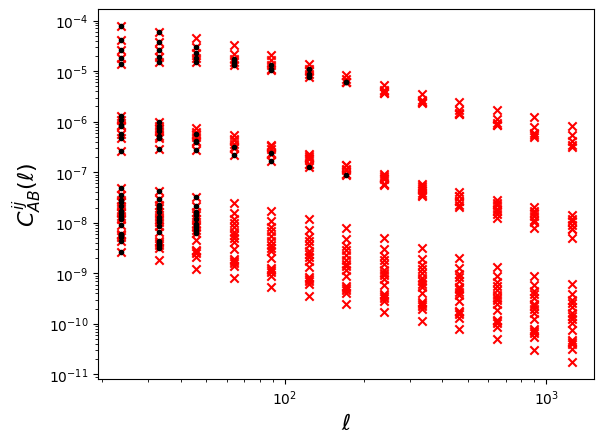

In [13]:
plt.scatter(npzfile['ell_data'],npzfile['C_ell_data'], color="r", marker='x')

for i in range(351):
    if gauss_invcov_rotated[0,i] !=0:
        plt.scatter(npzfile['ell_data'][i],npzfile['C_ell_data'][i], color="k", marker='.')

plt.xlabel("$\ell$",fontsize=16)
plt.ylabel("$C^{ij}_{AB}(\ell)$",fontsize=16)
plt.xscale("log")
plt.yscale("log")
#plt.savefig("LinearScaleCuts.pdf", bbox_inches='tight')


(351, 351)


/home/c2042999/PCA_project/Parameter_inference_GR/LikelihoodFuncts_PCADR_muSigma.py:1486: RuntimeWarning: invalid value encountered in divide
  return cov/np.outer(sig, sig)


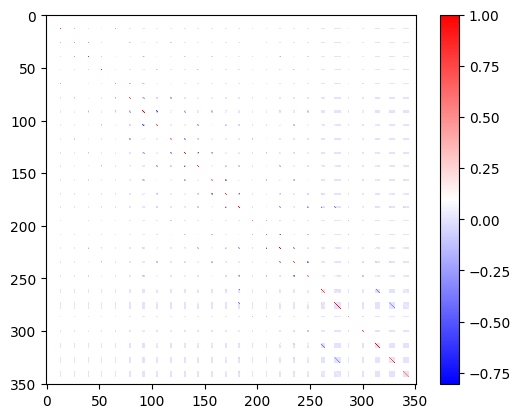

In [14]:
print(gauss_invcov_rotated.shape)
plt.imshow(cov2corr(gauss_invcov_rotated), origin='upper',  cmap='bwr')

plt.colorbar()
plt.show()

# Main

In [11]:
## add C_ell_data_mock, L_choleski_inv, Data_fsigma8
#### Define log probability #####
def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, C_ell_data_mock, L_choleski_inv,Data_fsigma8)

In [16]:
%%time
print(log_probability([0.27, 0.2,0.0, 2.1, 0.67, 0.96, 0.0223,1.562362,
                       1.732963,1.913252,2.100644,2.293210] ))

[[-3.70212804]]
CPU times: user 3.28 s, sys: 1.58 ms, total: 3.28 s
Wall time: 3.27 s


In [16]:
# Test likelihoods look reasonable

command = 'python Likelihood_nDGP_parallel_mpi_PCACuts_test.py'
os.system(command)

/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/nDGPemu/emulator.py:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/pkg_resources/__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/nDGPemu/emulator.py:43: DeprecationWarning: Use of .. or absolute path in a resource path is not allowed and will raise exceptions in a future release.
  self.model = joblib.load(resource_stream('nDGPemu','/cache/nDGPemu_LC_k5_woSN_PCA3_z2.joblib'))
/home/c2042999/PCA_env/3.8.1

Loading model and related data
Training the emulator at aexp=0.3333... done.
Training the emulator at aexp=0.3650... done.
Training the emulator at aexp=0.4000... done.
Training the emulator at aexp=0.4167... done.
Training the emulator at aexp=0.4444... done.
Training the emulator at aexp=0.4762... done.
Training the emulator at aexp=0.5000... done.
Training the emulator at aexp=0.5263... done.
Training the emulator at aexp=0.5556... done.
Training the emulator at aexp=0.5882... done.
Training the emulator at aexp=0.6250... done.
Training the emulator at aexp=0.6667... done.
Training the emulator at aexp=0.7042... done.
Training the emulator at aexp=0.7692... done.
Training the emulator at aexp=0.8000... done.
Training the emulator at aexp=0.8696... done.
Training the emulator at aexp=0.9091... done.
Training the emulator at aexp=0.9524... done.
Training the emulator at aexp=1.0000... 

/home/c2042999/PCA_project/Parameter_inference_nDGP/Likelihood_nDGP_parallel_mpi_PCACuts_test.py:246: PendingDeprecationWarning: the matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use regular ndarray.
  Data_fsigma8= [npzfile['z_eff_fsigma8'], npzfile['fsigma8_data'],np.matrix(npzfile['invcov_fsigma8'])]
/home/c2042999/PCA_project/Parameter_inference_nDGP/Likelihood_nDGP_parallel_mpi_PCACuts_test.py:248: PendingDeprecationWarning: the matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use regular ndarray.
  L_choleski_inv = np.matrix(npzfile_GR['L_ch_inv'])
/home/c2042999/PCA_project/Parameter_inference_nDGP/Likelihood_nDGP_parallel_mpi_PCACuts_test.py:250: PendingDeprecationWarning: the matrix subclass

done.
lp fid=  [[-100.91922836]]
lp random=  [[-118.28019991]]


0

In [15]:
# Set the random seed for reproducibility
np.random.seed(10)

# Initialize the walkers
Omega_c_est = 0.27
h_est = 0.67
A_s1e9_est = 2.1
n_s_est = 0.9621
mu0_est = 0.2
Sigma0_est = 0.05
wb_est = 0.0223
b1_est = Bias_distribution_fiducial[0][0]
b2_est = Bias_distribution_fiducial[1][0]
b3_est = Bias_distribution_fiducial[2][0]
b4_est = Bias_distribution_fiducial[3][0]
b5_est = Bias_distribution_fiducial[4][0]

n_steps = 15000
chain_len = 100
converged = False
nwalkers = 80
print(cpu_count())
# Initialize the walkers
pos = [Omega_c_est, mu0_est,Sigma0_est, A_s1e9_est, h_est, n_s_est, wb_est,b1_est,b2_est,b3_est,b4_est,b5_est] \
+ np.append(np.append(1e-3 * np.random.randn(nwalkers, 5), 1e-5*np.random.randn(nwalkers, 2), axis = 1), \
            1e-3 * np.random.randn(nwalkers, 5), axis = 1)

nwalkers, ndim = pos.shape
print(nwalkers, ndim)

# Create the output directory and set up the HDF5 backend
mcmc_dir = "mcmc"
filename = mcmc_dir + "/mcmc_nDGP_muSigma_PCACuts_noparam_nDGPonly.h5"
backend = emcee.backends.HDFBackend(filename)

# Optionally reset the backend if starting a new run
#backend.reset(nwalkers, ndim)

with Pool(80) as pool:
    sampler_PCA = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=backend, pool=pool)
    pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos

    while not converged:
        gc.collect(generation=0)
        sampler_PCA.run_mcmc(pos, chain_len, progress=True, store=True)
        
        # Clear references in the worker pool
        pool.close()
        pool.join()
        del pool  # Ensure the pool object is removed
        gc.collect()  # Collect any lingering garbage
        pool = Pool(80)
        sampler_PCA.pool = pool
        pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos
        
        # Check convergence
        try:
            tau = sampler_PCA.get_autocorr_time(tol=0)
            converged = np.all(tau * 100 < sampler_PCA.iteration)
        except emcee.autocorr.AutocorrError:
            pass

80
80 12


 76%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                                   | 76/100 [19:39<06:13, 15.57s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

 33%|████████████████████████████████████████████████▏                                                                                                 | 33/100 [08:41<17:37, 15.79s/it]Process ForkPoolWorker-5156:


emcee: Exception while calling your likelihood function:

Process ForkPoolWorker-5149:


emcee: Exception while calling your likelihood function:

...

[]

Process ForkPoolWorker-5190:
Process ForkPoolWorker-5173:
Process ForkPoolWorker-5174:
Process ForkPoolWorker-5165:
Process ForkPoolWorker-5123:
Process ForkPoolWorker-5199:
Process ForkPoolWorker-5192:
Process ForkPoolWorker-5197:
Process ForkPoolWorker-5164:
Process ForkPoolWorker-5185:


[]  args:[]  args:

Process ForkPoolWorker-5170:
Process ForkPoolWorker-5196:


Process ForkPoolWorker-5146:
Process ForkPoolWorker-5143:
Process ForkPoolWorker-5198:
Process ForkPoolWorker-5179:
Process ForkPoolWorker-5186:
Process ForkPoolWorker-5172:
Process ForkPoolWorker-5195:
Process ForkPoolWorker-5163:
Traceback (most recent call last):

KeyboardInterrupt

Traceback (most recent call last):
  File "/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/tmp/ipykernel_3038546/3141642000.py", line 7, in log_probability
    return lp + log_likelihood(theta, C_ell_data_mock, L_choleski_inv,Data_fsigma8)
  File "/tmp/ipykernel_3038546/3141642000.py", line 7, in log_probability
    return lp + log_likelihood(theta, C_ell_data_mock, L_choleski_inv,Data_fsigma8)
  File "/tmp/ipykernel_3038546/2925504416.py", l